In [17]:
from viafoundry.client import ViaFoundryClient
import json


In [ ]:
# Make sure to authenticate it
#client = ViaFoundryClient("~/.viaprod",  enable_session_history=True)
client = ViaFoundryClient("~/.viaenv")
# client.configure_auth(username="YOUR_USER", password="YOUR_PASSWORD", hostname="YOUR_VIA_HOST")

In [19]:
report_data = client.reports.fetch_report_data(report_id="1")

process_names = client.reports.get_process_names(report_data)
print("Processes:", process_names)
filenames = client.reports.get_file_names(report_data, "RSEM_module")
print(filenames)
# We will use file_path to load the data


Processes: ['MultiQC', 'DE_module_RSEM', 'RSEM_module', 'Salmon_module', 'Sequential_Mapping_Module', 'Bam_Quantify_Module_STAR', 'Overall_Summary']
                                     id  processName  \
0  8b2a2d73-cd5d-4106-ba55-755d1e30f38b  RSEM_module   
1  605c919e-ce3a-42bb-945f-18b34a2a85db  RSEM_module   
2  979d76fa-eee8-461d-b873-8ebe4160036e  RSEM_module   
3  76c90cb0-c5d4-48c7-b568-506ece5efe45  RSEM_module   

                                     name extension  \
0     genes_expression_expected_count.tsv       tsv   
1                genes_expression_tpm.tsv       tsv   
2  isoforms_expression_expected_count.tsv       tsv   
3             isoforms_expression_tpm.tsv       tsv   

                                           file_path  fileSize  \
0   rsem_summary/genes_expression_expected_count.tsv     65181   
1              rsem_summary/genes_expression_tpm.tsv     65639   
2  rsem_summary/isoforms_expression_expected_coun...     99601   
3           rsem_summary/isofo

In [20]:
rsem_data = client.reports.load_file(report_data, "rsem_summary/genes_expression_expected_count.tsv")
# To download the file you can use the line below.
# client.reports.download_file(report_data, "rsem_summary/genes_expression_expected_count.tsv")

print(rsem_data)

rsem_summary/genes_expression_expected_count.tsv
          gene                                   transcript  control_rep1  \
0       Zfp111                                   uc009foz.2          0.00   
1        Rps16                                   uc012fgr.1          0.00   
2     AB339385                                   uc029wdo.1          0.00   
3       Rasip1                                   uc009gwi.1        108.88   
4         Eml2                        uc009fkz.2,uc009fla.2          0.00   
...        ...                                          ...           ...   
1121    Nlrp4a  uc009ful.1,uc009fum.1,uc009fun.1,uc012fgc.1          0.00   
1122    Gm6164                        uc012fbs.1,uc012fdu.1          0.00   
1123    Zfp324             uc009fer.1,uc009fes.1,uc012ezd.1          0.00   
1124     C5ar1                        uc009fhl.2,uc012faf.1          0.00   
1125     Kcnc3                        uc009gqg.1,uc009gqh.1          0.00   

      control_rep2  contro

In [21]:
directories = client.reports.get_report_dirs(report_id="1")
print("Directories:", directories)

Directories: ['multiqc', 'Sequential_Mapping_Bam_count', 'rsem_summary', 'sequential_mapping_summary', 'featureCounts_after_STAR_summary', 'DESeq2_RSEM', 'summary', 'salmon_count', 'featureCounts_after_STAR_details', 'salmon_bam_count_star_summary']


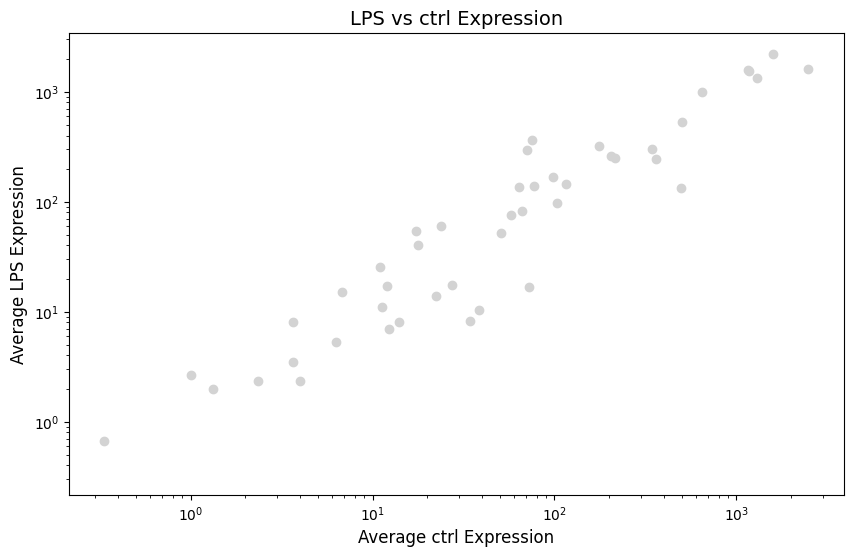

In [22]:
# prompt: Write a script to Create a scatter plot using rsem_data by getting the average of LPS vs ctrl columns in ligth grey and log Scale. The column prefixes are LPS and ctrl. Make sure to complete full column name yourself to get average for each condition. And save the file as plot.png

import pandas as pd
import matplotlib.pyplot as plt

# Assuming rsem_data is a pandas DataFrame
# Calculate the average of LPS and ctrl columns
lps_cols = [col for col in rsem_data.columns if col.startswith('control')]
ctrl_cols = [col for col in rsem_data.columns if col.startswith('exper')]

if not lps_cols or not ctrl_cols:
    print("No LPS or ctrl columns found in the data.")
else:
    rsem_data['LPS_avg'] = rsem_data[lps_cols].mean(axis=1)
    rsem_data['ctrl_avg'] = rsem_data[ctrl_cols].mean(axis=1)

    # Create the scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(rsem_data['ctrl_avg'], rsem_data['LPS_avg'], color='lightgrey')
    plt.xlabel('Average ctrl Expression', fontsize=12)
    plt.ylabel('Average LPS Expression', fontsize=12)
    plt.title('LPS vs ctrl Expression', fontsize=14)
    plt.xscale('log')
    plt.yscale('log')
    plt.savefig('plot.png')
    plt.show()

In [23]:
response = client.reports.upload_report_file(
    report_id="1",
    local_file_path="plot.png",
    dir="summary"
)

In [ ]:
client.reports.enable_session_history=True
response = client.reports.upload_session_history(
    report_id="1",
    dir="summary"
)

In [ ]:
%history